# Eye tracker analysis

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

from ML.model_training import (
    train_lstm,
    build_decod_lstm_sequences,
)
from ML import utils
import sys
import random
from itertools import product

# Data prep functions
def load_eego_df(
    filename: str | Path = "EEGo_labeled.csv",
) -> pd.DataFrame:
    """
    Load EEGo_labeled.csv and do minimal cleaning.
    """
    df = pd.read_csv(filename)

    # Sort by (user, session, time)
    sort_cols = ["user_id", "session_id"]
    if "time_elapsed" in df.columns:
        sort_cols.append("time_elapsed")
    elif "timestamp" in df.columns:
        sort_cols.append("timestamp")

    df = df.sort_values(sort_cols).reset_index(drop=True)
    return df

def select_eego_features(df: pd.DataFrame) -> list[str]:
    eeg_prefixes = [
        "AF3_", "F7_", "F3_", "FC5_", "T7_", "P7_",
        "O1_", "O2_", "P8_", "T8_", "FC6_", "F4_", "F8_", "AF4_",
    ]
    
    eeg_features = [
        c
        for c in df.columns
        if any(c.startswith(p) for p in eeg_prefixes)
    ]

    feature_cols = eeg_features
    return feature_cols

def balance_binary_sequences(
    X: np.ndarray, y: np.ndarray, seed: int = 5
) -> tuple[np.ndarray, np.ndarray]:
    """
    Downsample the majority class at the *sequence* level
    so that classes 0 and 1 are balanced.
    """
    rng = np.random.default_rng(seed)

    idx_pos = np.where(y == 1.0)[0]
    idx_neg = np.where(y == 0.0)[0]

    n_pos = len(idx_pos)
    n_neg = len(idx_neg)

    if n_pos == 0 or n_neg == 0 or n_pos == n_neg:
        return X, y

    if n_pos > n_neg:
        keep_pos = rng.choice(idx_pos, size=n_neg, replace=False)
        keep_idx = np.concatenate([keep_pos, idx_neg])
    else:
        keep_neg = rng.choice(idx_neg, size=n_pos, replace=False)
        keep_idx = np.concatenate([keep_neg, idx_pos])

    keep_idx = np.sort(keep_idx)
    return X[keep_idx], y[keep_idx]

Setup the DECOD dataset with features and identify and organize sessions.
Create a feature table using eegproc.

In [2]:
# Load data
df_eego = load_eego_df("DECOD/DECOD.csv")
print("DECOD shape:", df_eego.shape)

TEXT_VERSION = "text_version"
AROUSAL = "arousal"

df_eego[AROUSAL] = np.nan

df_eego.loc[df_eego[TEXT_VERSION] > 20, AROUSAL] = 1
df_eego.loc[
    (df_eego[TEXT_VERSION] > 10) & (df_eego[TEXT_VERSION] <= 20),
    AROUSAL
] = 0

df_eego = df_eego[df_eego[AROUSAL].isin([0, 1])].copy()
print("Binary df shape:", df_eego.shape)
counts = df_eego[AROUSAL].value_counts()

print(counts)
print(counts[1]/(counts[1]+counts[0]))

DECOD shape: (14250, 81)
Binary df shape: (9227, 81)
arousal
0.0    5231
1.0    3996
Name: count, dtype: int64
0.4330768397095481


## Mean and STD of timestamp differences.

In [30]:
# Make sure timestamp is numeric (float) and stamps are datetimes
df_eego["timestamp"] = pd.to_numeric(df_eego["timestamp"], errors="coerce")
df_eego["start_stamp"] = pd.to_datetime(df_eego["start_stamp"])
df_eego["end_stamp"] = pd.to_datetime(df_eego["end_stamp"])

# Convert start/end stamps to unix seconds so they’re comparable to `timestamp`
df_eego["start_unix"] = df_eego["start_stamp"].astype("int64") / 1e9
df_eego["end_unix"] = df_eego["end_stamp"].astype("int64") / 1e9

# Define what a "batch" is
group_cols = [
    "user_id",
    "session_id",
    "start_stamp",
    "end_stamp",
    "eye_id",
    "text_version",
]

batch_stats = (
    df_eego
    .groupby(group_cols, as_index=False)
    .agg(
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"),
        start_unix=("start_unix", "first"),
        end_unix=("end_unix", "first"),
    )
)

# Per-batch differences (in seconds)
batch_stats["start_diff"] = batch_stats["first_timestamp"] - batch_stats["start_unix"] + 5
batch_stats["end_diff"] = batch_stats["end_unix"] - batch_stats["last_timestamp"]
batch_stats["ts_duration"] = batch_stats["last_timestamp"] - batch_stats["first_timestamp"]
batch_stats["stamp_duration"] = batch_stats["end_unix"] - batch_stats["start_unix"]
batch_stats["duration_diff"] = batch_stats["stamp_duration"] - batch_stats["ts_duration"] + 5

# Now get global mean/std
print("Start offset: mean, std (s)", batch_stats["start_diff"].mean(), batch_stats["start_diff"].std())
print("End offset:   mean, std (s)", batch_stats["end_diff"].mean(),   batch_stats["end_diff"].std())
print("Dur diff:     mean, std (s)", batch_stats["duration_diff"].mean(), batch_stats["duration_diff"].std())


Start offset: mean, std (s) -1.30776930482764 2.368730323588341
End offset:   mean, std (s) 0.24165877124719454 0.5189651319725984
Dur diff:     mean, std (s) -1.0661105335804455 2.4243028549317773


## Find missing words

In [4]:
import ast
import re
import numpy as np
import pandas as pd

# --- helper to ensure we have dicts and extract IDs ---
word_id_pattern = re.compile(r"word_(\d+)_")

def extract_word_ids(seen):
    if pd.isna(seen):
        return set()
    if isinstance(seen, str):
        try:
            seen = ast.literal_eval(seen)
        except Exception:
            return set()
    # now `seen` should be a dict
    ids = set()
    for k in seen.keys():
        m = word_id_pattern.match(k)
        if m:
            ids.add(int(m.group(1)))
    return ids

df_eego["word_ids"] = df_eego["seen_words"].apply(extract_word_ids)


In [23]:
# Make sure ordering is deterministic within each session
df_eego = df_eego.sort_values(["user_id", "session_id", "timestamp"]).copy()

df_eego["idx_in_session"] = df_eego.groupby(["user_id", "session_id"]).cumcount()
df_eego["last_idx_in_session"] = df_eego.groupby(["user_id", "session_id"])["idx_in_session"].transform("max")

# Middle batches only: ignore first (0) and last (last_idx)
# middle_mask = df_eego["idx_in_session"].between(1, df_eego["last_idx_in_session"] - 1)


In [26]:
def missing_ids_for_session(group: pd.DataFrame) -> pd.Series:
    # group is already sorted by timestamp from above
    if len(group) <= 2:
        # nothing but first/last batch
        return pd.Series(
            {"missed_ids": np.nan, "min_id": np.nan, "max_id": np.nan}
        )
    
    # middle rows only
    mid = group.iloc[1:-1]
    # union all word IDs across middle batches
    all_ids = set().union(*mid["word_ids"].tolist())
    
    if not all_ids:
        return pd.Series(
            {"missed_ids": np.nan, "min_id": np.nan, "max_id": np.nan}
        )
    
    min_id = min(all_ids)
    max_id = max(all_ids)
    full_range = set(range(min_id, max_id + 1))
    missing = full_range - all_ids
    
    return pd.Series(
        {"missed_ids": len(missing), "min_id": min_id, "max_id": max_id}
    )

session_missing = (
    df_eego
    .groupby(["user_id", "session_id"], group_keys=False)
    .apply(missing_ids_for_session)
    .reset_index()
)

print(session_missing)
print("Missed:", str(session_missing["missed_ids"]/session_missing["max_id"]*100) + "%")
print("Mean missed IDs per session:", session_missing["missed_ids"].mean())
print("Average Max id:", session_missing["max_id"].mean())
print("Std missed IDs per session: ", session_missing["missed_ids"].std())


    user_id                            session_id  missed_ids  min_id  max_id
0         0  2637835c-3782-4e6d-9920-1c0126e785f3          42       1     110
1         0  35d4a6c2-2b29-4260-b5d5-a7244c457596          15       1     110
2         0  3bea4e63-e6ac-4000-bd62-1b69c0a3b6a5          26       1     106
3         0  3d5b14ed-b668-46c5-9a60-0b7af63f9658          10       0      87
4         0  56c06616-46ed-4076-b184-895ca1d44207          26       1     106
5         0  676d1be3-da11-466a-9f5e-d7fb3cc987da          29       1     110
6         0  6981c2cf-d7e3-414a-bf4b-aba1b33fcc5e          27       1     110
7         0  6b38fd78-439c-481f-88fd-2198f11a8c78          41       1      98
8         0  7731616d-54c3-45dc-abc3-b67908893710          35       1     112
9         0  b192fe37-1e4d-4cf0-8ed8-29ea2ea0b1cd          24       1     112
10        0  b5227a42-487c-4160-b69d-b20606940320          30       1     110
11        0  cf2e7ce6-2d76-4ba9-bbf5-93a0d45cc4f0          31   

/var/folders/49/1c42163d32534fckyhl61hkr0000gp/T/ipykernel_27149/4002274749.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(missing_ids_for_session)


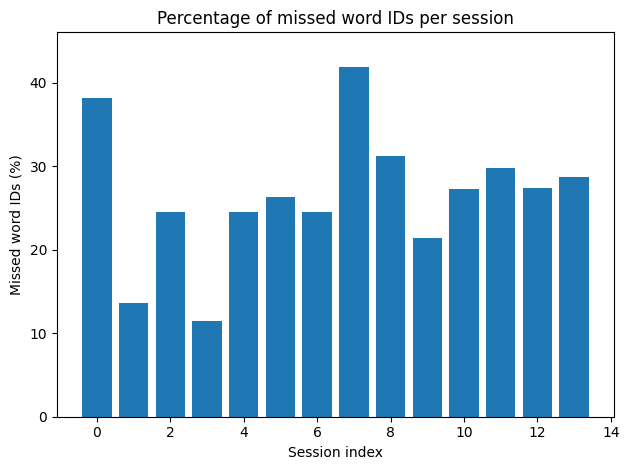

In [27]:
import matplotlib.pyplot as plt

# Compute percentage missed per session
missed_pct = session_missing["missed_ids"] / session_missing["max_id"] * 100

fig, ax = plt.subplots()
ax.bar(session_missing.index, missed_pct)
ax.set_xlabel("Session index")
ax.set_ylabel("Missed word IDs (%)")
ax.set_title("Percentage of missed word IDs per session")
ax.set_ylim(0, missed_pct.max() * 1.1)
plt.tight_layout()
plt.show()